In [2]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
from phate.tree import gen_dla

In [30]:
DATA_PARAMS = {
    "n_branch": 10,
    "n_dim": 50,
    "branch_length": 80,
}
X, labels =  gen_dla(**DATA_PARAMS)

In [31]:
X_uphate, X_bootstrap, grad = (
    jnp.load("X_uphate.npy"),
    jnp.load("boostrap_embeddings.npy"),
    jnp.load("gradient_magnitudes.npy"),
)

coord_std = jnp.std(X_bootstrap, axis=0)
single_std = jnp.linalg.norm(coord_std, axis=1)
single_grad = jnp.linalg.norm(grad, axis=1)
corr = scipy.stats.spearmanr(single_std, single_grad)
corr

SignificanceResult(statistic=0.5993868037293809, pvalue=3.4431622885781984e-79)

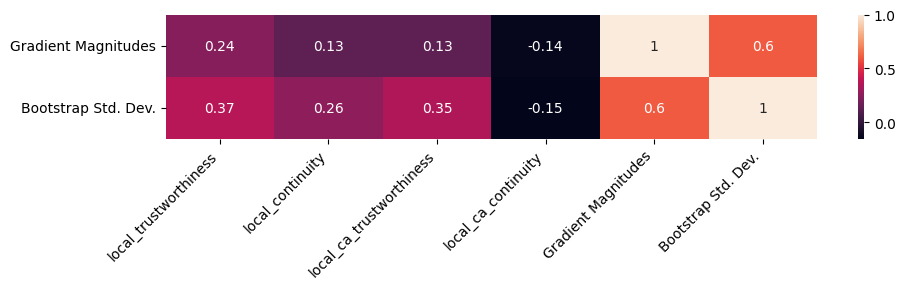

In [37]:
from zadu import zadu

spec = [
    {
        "id": "tnc",
        "params": {"k": 20},
    },
    {
        "id": "ca_tnc",
        "params": {"k": 20},
    },
]
global_scores, (local_tnc, local_ca_tnc) = zadu.ZADU(
    spec, X, return_local=True
).measure(X_uphate, label=labels)

data = dict(**local_tnc, **local_ca_tnc)
data["Gradient Magnitudes"] = single_grad
data["Bootstrap Std. Dev."] = single_std

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(pd.DataFrame(data).corr("spearman").loc[["Gradient Magnitudes", "Bootstrap Std. Dev."], :], ax=ax, annot=True)
ax.set_xticklabels(data.keys(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig("figures/metric_correlations.png", dpi=300)

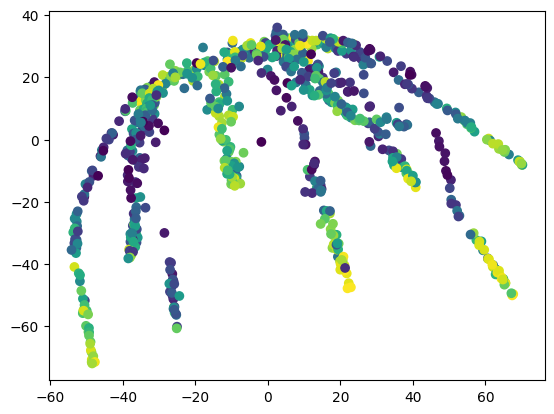

In [27]:
metric = "local_ca_continuity"
plt.scatter(*X_uphate.T, c=jnp.argsort(jnp.argsort(data[metric])))

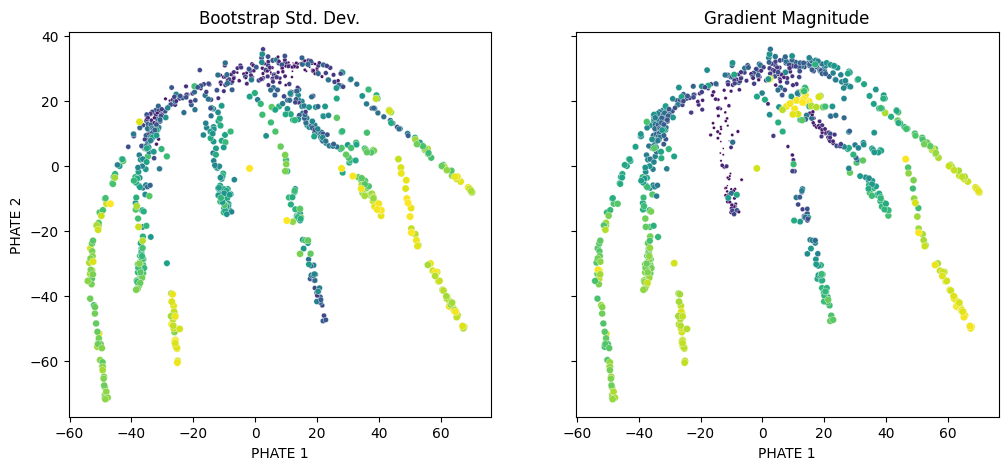

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
size_transform = lambda x: (x + 1) ** 0.5

for i,( name, uncertainty_metric) in enumerate([
    ("Bootstrap Std. Dev.", single_std),
    ("Gradient Magnitude", single_grad),
]):
    rank = jnp.argsort(jnp.argsort(uncertainty_metric))
    sns.scatterplot(
        x=X_uphate[:, 0],
        y=X_uphate[:, 1],
        c=rank,
        ax=axes[i],
        s=size_transform(rank),
    )
    axes[i].set_title(name)
    axes[i].set_xlabel("PHATE 1")
    axes[i].set_ylabel("PHATE 2")

fig.savefig("figures/uncertainty_comparison.png", dpi=300)